<a href="https://colab.research.google.com/github/Ronaldo-Junior1/analise-dados-atividade2/blob/main/ArquivoPrincipal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

In [8]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Analise_dados"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
CAMINHO_CSV = 'A519.csv'

df_raw = pd.read_csv(f'{path}/{CAMINHO_CSV}', sep=';')

print(f'Shape original: {df_raw.shape}')
print(f'Período: {df_raw["data"].min()} → {df_raw["data"].max()}')
print()
df_raw.head(10)

Shape original: (83232, 9)
Período: 2013-12-03 → 2023-06-01



,data,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,Unnamed: 8
0,2013-12-03,0,949.3,-3.540,22.3,21.0,92.0,2.3,NaN
1,2013-12-03,100,949.7,-3.540,22.1,20.6,91.0,2.1,NaN
2,2013-12-03,200,949.4,-3.540,22.1,20.0,88.0,1.3,NaN
3,2013-12-03,300,949.1,-3.540,21.9,20.2,90.0,2.3,NaN
4,2013-12-03,400,948.6,-3.540,21.4,19.8,91.0,1.5,NaN
5,2013-12-03,500,947.8,-3.540,21.2,19.8,92.0,2.0,NaN
6,2013-12-03,600,947.3,-3.540,20.8,19.4,92.0,1.8,NaN
7,2013-12-03,700,947.7,-3.540,20.4,19.6,95.0,1.7,NaN
8,2013-12-03,800,948.3,-3.445,20.4,19.7,95.0,1.8,NaN
9,2013-12-03,900,949.2,38.054,20.6,19.8,95.0,1.9,NaN


In [20]:
print('Tipos de dados')
print(df_raw.dtypes)
print()
print('Valores nulos por coluna')
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
pd.DataFrame({'Nulos': nulos, '% do Total': nulos_pct})

Tipos de dados
data                 object
hora                  int64
pressao             float64
radiacao            float64
temp_inst           float64
pto_orvalho_inst    float64
umid_inst           float64
vento_vel           float64
Unnamed: 8          float64
dtype: object

Valores nulos por coluna


,Nulos,% do Total
data,0,0.00
hora,0,0.00
pressao,5279,6.34
radiacao,5279,6.34
temp_inst,5279,6.34
pto_orvalho_inst,5284,6.35
umid_inst,5285,6.35
vento_vel,5279,6.34
Unnamed: 8,83232,100.00


In [13]:
print('=== Estatísticas Descritivas ===')
df_raw.describe().round(2)

=== Estatísticas Descritivas ===


,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,Unnamed: 8
count,83232.00,77953.00,77953.00,77953.00,77948.00,77947.00,77953.00,0.0
mean,1150.00,950.65,854.66,24.27,15.97,64.33,1.80,NaN
std,692.22,3.18,1127.04,5.12,4.97,21.08,1.38,NaN
min,0.00,938.90,-3.54,2.00,-10.00,8.00,0.00,NaN
25%,575.00,948.50,-3.53,21.00,12.50,49.00,0.80,NaN
50%,1150.00,950.50,79.66,23.60,17.30,67.00,1.50,NaN
75%,1725.00,952.70,1727.16,28.10,19.80,82.00,2.50,NaN
max,2300.00,963.00,4291.43,40.90,33.20,100.00,10.30,NaN


**Observações iniciais:**
- O dataset possui **83.232 registros horários** cobrindo aproximadamente **10 anos** (dez/2013 a jun/2023).
- A coluna `Unnamed: 8` é um artefato do separador final em cada linha — será removida.
- As colunas `pressao`, `radiacao`, `temp_inst`, `pto_orvalho_inst`, `umid_inst` e `vento_vel` possuem **~5.279–5.285 valores nulos** (~6,3%), provavelmente blocos de falha do sensor.
- A coluna `hora` está codificada como inteiro no formato HHMM (ex: `0`, `100`, `200`, ..., `2300`) e precisa de conversão.

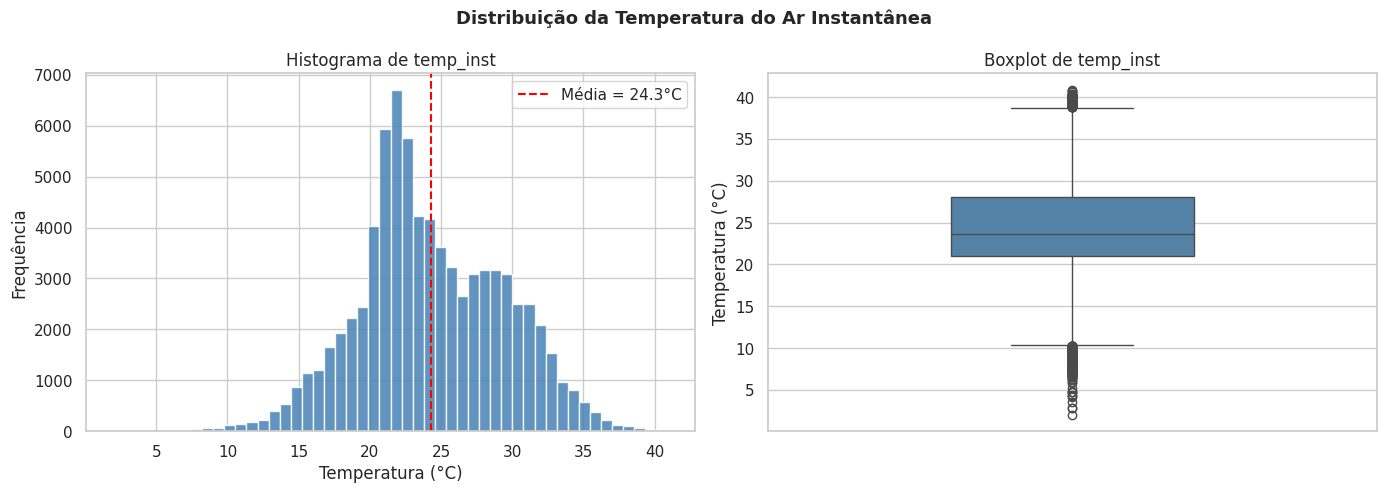

Mínimo: 2.0°C | Máximo: 40.9°C
Média: 24.27°C | Mediana: 23.60°C
Desvio Padrão: 5.12°C


In [16]:

df_analise = df_raw.drop(columns=['Unnamed: 8']).dropna().copy()
df_analise['data'] = pd.to_datetime(df_analise['data'])
df_analise['hora_int'] = df_analise['hora'] // 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_analise['temp_inst'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Histograma de temp_inst')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df_analise['temp_inst'].mean(), color='red', linestyle='--', label=f'Média = {df_analise["temp_inst"].mean():.1f}°C')
axes[0].legend()

sns.boxplot(y=df_analise['temp_inst'], ax=axes[1], color='steelblue', width=0.4)
axes[1].set_title('Boxplot de temp_inst')
axes[1].set_ylabel('Temperatura (°C)')

plt.suptitle('Distribuição da Temperatura do Ar Instantânea', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mínimo: {df_analise["temp_inst"].min():.1f}°C | Máximo: {df_analise["temp_inst"].max():.1f}°C')
print(f'Média: {df_analise["temp_inst"].mean():.2f}°C | Mediana: {df_analise["temp_inst"].median():.2f}°C')
print(f'Desvio Padrão: {df_analise["temp_inst"].std():.2f}°C')

**Análise:** A distribuição de `temp_inst` é aproximadamente normal, ligeiramente assimétrica à direita, com a maioria dos registros entre **18°C e 32°C**. Os valores extremos (2°C e 40,9°C) são **fisicamente plausíveis** para uma estação meteorológica no interior de São Paulo, no momento não iremos remover.

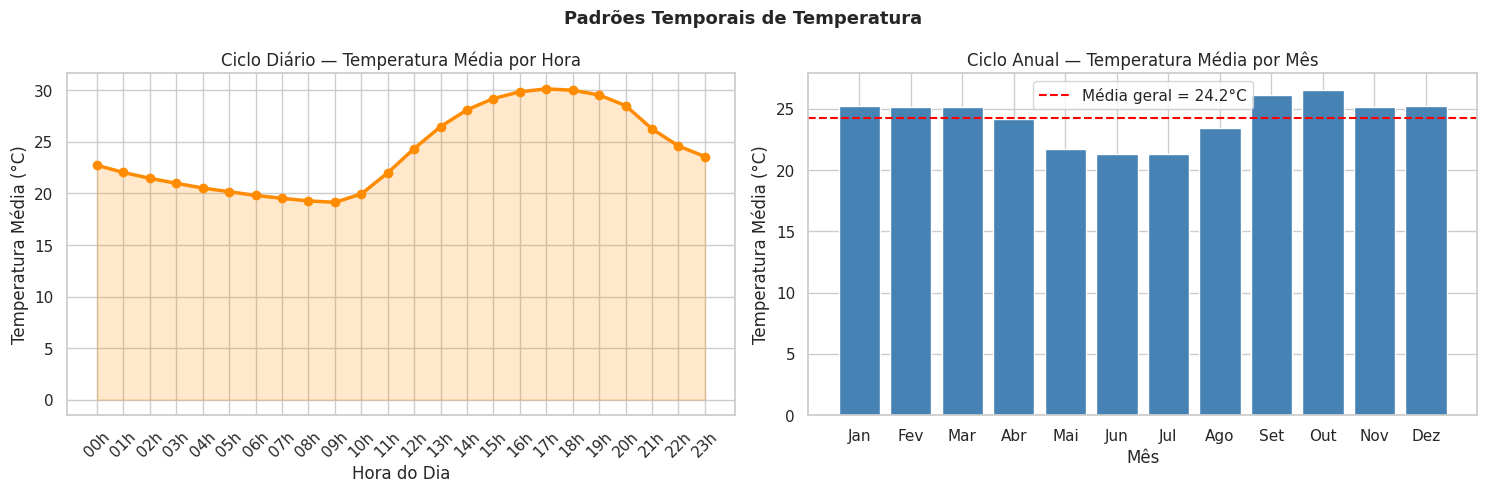

In [17]:
df_analise['mes'] = df_analise['data'].dt.month
nomes_mes = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
             7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

temp_hora = df_analise.groupby('hora_int')['temp_inst'].mean()
temp_mes  = df_analise.groupby('mes')['temp_inst'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(temp_hora.index, temp_hora.values, marker='o', color='darkorange', linewidth=2.5)
axes[0].fill_between(temp_hora.index, temp_hora.values, alpha=0.2, color='darkorange')
axes[0].set_title('Ciclo Diário — Temperatura Média por Hora')
axes[0].set_xlabel('Hora do Dia')
axes[0].set_ylabel('Temperatura Média (°C)')
axes[0].set_xticks(range(0, 24))
axes[0].set_xticklabels([f'{h:02d}h' for h in range(0,24)], rotation=45)

axes[1].bar([nomes_mes[m] for m in temp_mes.index], temp_mes.values, color='steelblue', edgecolor='white')
axes[1].set_title('Ciclo Anual — Temperatura Média por Mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Temperatura Média (°C)')
axes[1].axhline(temp_mes.mean(), color='red', linestyle='--', label=f'Média geral = {temp_mes.mean():.1f}°C')
axes[1].legend()

plt.suptitle('Padrões Temporais de Temperatura', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Análise:**
- **Ciclo diário:** A temperatura atinge seu mínimo por volta das **8–9h** (19°C) e seu máximo às **17–18h** (30°C), apresentando variação diária de 11°C.
- **Ciclo anual:** Os meses mais quentes são setembro-outubro (26°C) e os mais frios são junho-julho (21°C), refletindo a sazonalidade do interior paulista.